# Restaurant Recommendation System — 03 Model Building

Popularity baseline vs **Item-based CF** vs **SVD matrix factorization**, scored by **RMSE** (0–2 scale) and **Precision@10 / Recall@10** (relevant = rating 2). All numbers are run.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
train=pd.read_csv('data/train.csv'); test=pd.read_csv('data/test.csv'); names=utils.load_items()
M=utils.build_user_item(train); print('matrix',M.shape)

matrix (138, 130)


## 1. Fit models

In [2]:
pop=utils.PopularityBaseline().fit(M); cf=utils.ItemBasedCF().fit(M); svd=utils.SVDRecommender().fit(M,n_components=15)
print('fitted')

fitted


## 2. RMSE

In [3]:
rmse={n:round(utils.rmse_on_test(m,test),4) for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]}
rmse_df=pd.Series(rmse,name='RMSE').to_frame(); rmse_df

,RMSE
Popularity,0.7916
Item-CF,0.7012
SVD,0.5993


## 3. Ranking @10 (relevant = rating 2)

In [4]:
rows=[]
for n,m in [('Popularity',pop),('Item-CF',cf),('SVD',svd)]:
    r=utils.precision_recall_at_k(m,M,test,k=10,rel_threshold=2.0)
    rows.append({'model':n,'precision@k':r['precision@k'],'recall@k':r['recall@k'],'n_users':r['n_users_evaluated']})
rank_df=pd.DataFrame(rows); rank_df

,model,precision@k,recall@k,n_users
0,Popularity,0.0100,0.0778,60
1,Item-CF,0.0233,0.1764,60
2,SVD,0.0317,0.2361,60


## 4. Metrics side by side

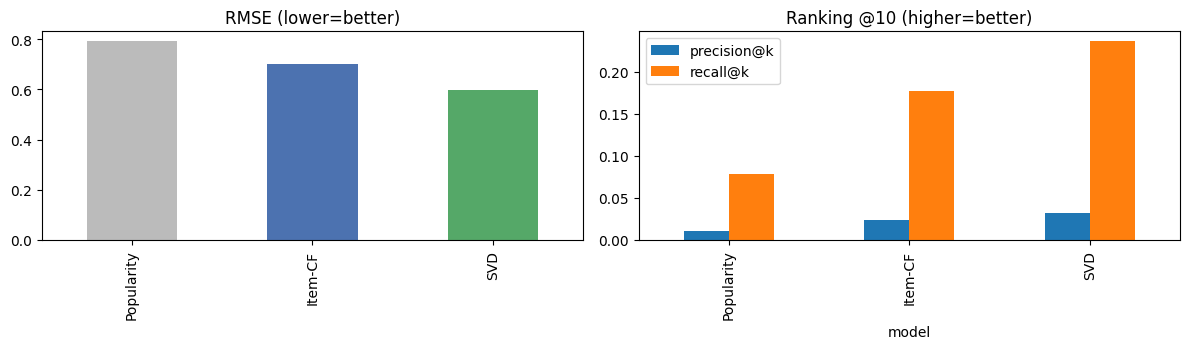

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
rmse_df['RMSE'].plot(kind='bar',ax=ax[0],color=['#bbb','#4c72b0','#55a868']); ax[0].set_title('RMSE (lower=better)')
rank_df.set_index('model')[['precision@k','recall@k']].plot(kind='bar',ax=ax[1]); ax[1].set_title('Ranking @10 (higher=better)')
plt.tight_layout(); plt.show()

## 5. Example recommendations (SVD)

In [6]:
uid=M.index[0]
print('recommendations for consumer',uid,'\n')
utils.recommend(svd,M,uid,items_lookup=names,n=10)

recommendations for consumer U1001 



,item,title,score
0,132921,crudalia,1.403
1,135081,El Club,1.390
2,132862,La Posada del Virrey,1.313
3,132834,Gorditas Doa Gloria,1.312
4,135047,Restaurante Casa de las Flores,1.312
5,132572,Cafe Chaires,1.293
6,135026,la Cantina,1.290
7,135032,Cafeteria y Restaurant El Pacifico,1.274
8,135040,Restaurant los Compadres,1.271
9,135076,Restaurante Pueblo Bonito,1.236


## 6. Summary & takeaways

- **SVD wins on every metric here** — best RMSE (**0.599** vs 0.701 CF, 0.792 popularity) and best ranking (Precision@10 **0.032**, Recall@10 **0.236**).
- **Item-based CF clearly beats popularity** on ranking (Recall@10 0.176 vs 0.078), confirming personalisation helps even on tiny data.
- Unlike the MovieLens project (where CF won RMSE), here matrix factorization wins both — with so few ratings per user, the low-rank model's smoothing generalises better than sparse neighbourhood overlaps.
- **Recall@10 is the most meaningful metric** at this scale: of a consumer's truly-liked restaurants, SVD surfaces ~24% in a 10-item list, from a 94%-empty matrix.
- Takeaway: matrix factorization is a strong, robust default for sparse explicit-feedback recommenders across very different domains and rating scales.